#### Model with Gating at position G (at attention calculation step) :  As in Paper where stated best effective

In [ ]:
### Aplied gated atention at position G elementwise

In [ ]:
# Rope

def compute_rope_params(seq_len, head_dim, device=None):
    # x: (seq_len, dim)

    assert head_dim % 2 == 0, "head_dim must be even for RoPE"

    theta = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float() / head_dim))

    pos = torch.arange(seq_len).float()

    angles = pos[:, None] * theta[None, :]


    angles = angles[None, None, :, :]

    return torch.cos(angles), torch.sin(angles)



# similar to sebastian
def apply_rope(x, cos, sin, offset=0):

    batch_size, num_heads, seq_len, head_dim = x.shape   # (batch_size, num_heads, seq_len, head_dim)

    assert head_dim % 2 == 0, "Head dimension must be even"

    cos_sel = cos[...,offset : offset + seq_len, :].to(x.device, x.dtype)  #(1,1,seq_len,head_dim//2)
    sin_sel = sin[..., offset : offset + seq_len, :].to(x.device, x.dtype)

    x_even = x[..., 0::2]  # (b,n_heads,seq_len,head_dim//2)
    x_odd  = x[..., 1::2]


    x_rot = torch.empty_like(x)

    x_rot[..., 0::2] = x_even * cos_sel - x_odd * sin_sel
    x_rot[..., 1::2] = x_even * sin_sel + x_odd * cos_sel

    return x_rot.to(dtype=x.dtype)

In [ ]:
import torch
from torch import nn


class causal_multi_head_transformer(nn.Module):
    def __init__(self, din, dout, context_length, dropout, ff_dim, num_heads, qk_norm, vocab_size, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads

        assert dout % num_heads == 0, f"d_out must be divisible by num_heads {dout // num_heads}"

        self.head_dim = dout // num_heads

        self.context_length = context_length



        self.wq = nn.Linear(din, dout, bias = qkv_bias)
        self.wk = nn.Linear(din, dout, bias = qkv_bias)
        self.wv = nn.Linear(din, dout, bias = qkv_bias)
        self.dropout = nn.Dropout(dropout)

        self.out_proj = nn.Linear(dout, dout)  # Linear layer to combine head outputs


        # Feedforward
        self.ff = nn.Sequential(nn.Linear(din, ff_dim),
                                            nn.ReLU(), nn.Linear(ff_dim, din),)
        self.norm1 = nn.RMSNorm(din)
        self.norm2 = nn.RMSNorm(din)

        self.apply_rope = apply_rope

        self.gate = nn.Linear(din, self.num_heads * self.head_dim)

        nn.init.normal_(self.gate.weight, std=0.02)
        nn.init.constant_(self.gate.bias, 0.0)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length, dtype=torch.bool), diagonal=1)
        )

        self.qk_norm  = qk_norm


    def forward(self, x, cos, sin, start_pos):

        b, num_tokens, d_in = x.shape

        assert num_tokens <= self.context_length

        #Pre-LN
        x_norm = self.norm1(x)

        q = self.wq(x_norm)
        k = self.wk(x_norm)
        v = self.wv(x_norm)

        k = k.view(b, num_tokens, self.num_heads, self.head_dim)
        v = v.view(b, num_tokens, self.num_heads, self.head_dim)
        q = q.view(b, num_tokens, self.num_heads, self.head_dim)


        k = k.transpose(1,2)  # reshape to (b, num_heads, num_tokens, head_dim)
        v = v.transpose(1,2)
        q = q.transpose(1,2)

          #QK normalization (optional)
        if self.qk_norm:
            q = q / (q.norm(dim=-1, keepdim=True) + 1e-6)
            k = k / (k.norm(dim=-1, keepdim=True) + 1e-6)

        q_enc = self.apply_rope(q, cos, sin, start_pos)
        k_enc = self.apply_rope(k, cos, sin, start_pos)

        attn_scores = q_enc @ k_enc.transpose(2,3)    # (b, num_heads, num_tokens, head_dim) @ (b, num_heads, head_dim, num_tokens)

        if not self.qk_norm:
            attn_scores = attn_scores / (self.head_dim ** 0.5)

        mask = self.mask[:num_tokens, :num_tokens]
        masked = attn_scores.masked_fill(mask.bool(), float('-inf'))

        attn_weights = torch.softmax(masked, dim=-1)                             # shape: (b, num_heads, num_tokens, num_tokens)
        attn_weights = self.dropout(attn_weights)
        z = (attn_weights @ v)

        #gate applied elemnetwise

        gate_val = self.gate(x_norm)

        gate_val = gate_val.view(b, num_tokens, self.num_heads, self.head_dim)
        gate_val = gate_val.transpose(1,2)


        z = z * torch.sigmoid(gate_val)

       # Reshape and project
        z = z.transpose(1,2).contiguous().view(b, num_tokens, -1)  # Reshape to (b, num_tokens, num_heads, head_dim)
        attn_out = self.out_proj(z)

        # after attention output

        # Pre-LN
        x= x + attn_out
        x = x + self.ff(self.norm2(x))

        sink_val = attn_weights[:, :, :, 0].mean(dim=-1)

        return x, gate_val, sink_val

In [ ]:
class Gated_Transformer_LM(nn.Module):
  def __init__(self, din, dout, context_length, dropout, ff_dim, num_heads, vocab_size, qk_norm, n_transformer):
    super().__init__()


    assert din == dout

    self.embedding = nn.Embedding(vocab_size, din)


    self.dstack = nn.ModuleList([causal_multi_head_transformer(din, dout, context_length, dropout, ff_dim, num_heads, qk_norm, vocab_size)
    for _ in range(n_transformer)])

    cos, sin = compute_rope_params(context_length, din//num_heads)

    # register so they move with the model and are saved in state_dict
    self.register_buffer("rope_cos", cos)
    self.register_buffer("rope_sin", sin)

    self.cos, self.sin = cos, sin

    self.final_norm = nn.RMSNorm(din)
    self.out_head = nn.Linear(
        din, vocab_size, bias=False
    )


  def forward(self, inp, start_pos: int = 0):
      gate_vals = []
      attn_sink_val = []

      x = self.embedding(inp)

      for layer in self.dstack:
        x, gate_val, sink_info = layer(x, self.cos, self.sin, start_pos)

        gate_vals.append(gate_val)
        attn_sink_val.append(sink_info)

      x = self.final_norm(x)
      logits = self.out_head(x)


      return logits, gate_vals, attn_sink_val # Only return logits, as gate_val is not computed

### Model without Gating

In [ ]:
import torch
from torch import nn

class causal_multi_head_transformer_no_gate(nn.Module):
    def __init__(self, din, dout, context_length, dropout, ff_dim, num_heads, qk_norm, vocab_size, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads

        assert dout % num_heads == 0, f"d_out must be divisible by num_heads {dout // num_heads}"

        self.head_dim = dout // num_heads

        self.context_length = context_length

        self.wq = nn.Linear(din, dout, bias = qkv_bias)
        self.wk = nn.Linear(din, dout, bias = qkv_bias)
        self.wv = nn.Linear(din, dout, bias = qkv_bias)
        self.dropout = nn.Dropout(dropout)

        self.out_proj = nn.Linear(dout, dout)  # Linear layer to combine head outputs


        # Feedforward
        self.ff = nn.Sequential( nn.Linear(din, ff_dim),
                                            nn.ReLU(), nn.Linear(ff_dim, din), )
        self.norm1 = nn.RMSNorm(din)
        self.norm2 = nn.RMSNorm(din)

        self.apply_rope = apply_rope

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length, dtype=torch.bool), diagonal=1)
        )

        self.qk_norm  = qk_norm


    def forward(self, x, cos, sin, start_pos):

        b, num_tokens, d_in = x.shape

        assert num_tokens <= self.context_length

        #Pre-LN
        x_norm = self.norm1(x)

        q = self.wq(x_norm)
        k = self.wk(x_norm)
        v = self.wv(x_norm)

        k = k.view(b, num_tokens, self.num_heads, self.head_dim)
        v = v.view(b, num_tokens, self.num_heads, self.head_dim)
        q = q.view(b, num_tokens, self.num_heads, self.head_dim)


        k = k.transpose(1,2)  # reshape to (b, num_heads, num_tokens, head_dim)
        v = v.transpose(1,2)
        q = q.transpose(1,2)

          #QK normalization (optional)
        if self.qk_norm:
            q = q / (q.norm(dim=-1, keepdim=True) + 1e-6)
            k = k / (k.norm(dim=-1, keepdim=True) + 1e-6)

        q_enc = self.apply_rope(q, cos, sin, start_pos)
        k_enc = self.apply_rope(k, cos, sin, start_pos)

        attn_scores = q_enc @ k_enc.transpose(2,3)

        if not self.qk_norm:
            attn_scores = attn_scores / (self.head_dim ** 0.5)

        mask = self.mask[:num_tokens, :num_tokens]
        masked = attn_scores.masked_fill(mask.bool(), float('-inf'))

        attn_weights = torch.softmax(masked, dim=-1)
        attn_weights = self.dropout(attn_weights)
        z = (attn_weights @ v)

        # Gating mechanism removed

       # Reshape and project
        z = z.transpose(1,2).contiguous().view(b, num_tokens, -1)  # Reshape to (b, num_tokens, num_heads, head_dim)
        attn_out = self.out_proj(z)

        # after attention output

        #  Pre-LN
        x= x + attn_out
        x = x + self.ff(self.norm2(x))

        sink_val = attn_weights[:, :, :, 0].mean(dim=-1)

        return x,  sink_val # Only return x, as gate_val is not computed

In [ ]:
x  =torch.tensor([[12,12]])

In [ ]:
class Transformer_No_Gate(nn.Module):
  def __init__(self, din, dout, context_length, dropout, ff_dim, num_heads, vocab_size, qk_norm, n_transformer):
    super().__init__()

    self.embedding = nn.Embedding(vocab_size, din)


    self.dstack = nn.ModuleList([causal_multi_head_transformer_no_gate(din, dout, context_length, dropout, ff_dim, num_heads, qk_norm, vocab_size)
    for _ in range(n_transformer)])

    cos, sin = compute_rope_params(context_length, din//num_heads)

    # register so they move with the model and are saved in state_dict
    self.register_buffer("rope_cos", cos)
    self.register_buffer("rope_sin", sin)

    self.cos, self.sin = cos, sin

    self.final_norm = nn.RMSNorm(din)
    self.out_head = nn.Linear(
        din, vocab_size, bias=False
    )


  def forward(self, inp, start_pos: int = 0):
      attn_sink_val = []
      x = self.embedding(inp)

      for layer in self.dstack:
        x, sink_info = layer(x, self.cos, self.sin, start_pos)
        attn_sink_val.append(sink_info)

      x = self.final_norm(x)
      logits = self.out_head(x)


      return logits, attn_sink_val # Only return logits, as gate_val is not computed


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer


# -----------------------------
# Load Dataset
# -----------------------------
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

texts = dataset["train"]["text"]
texts = [t for t in texts if len(t.strip()) > 0]


# -----------------------------
# Tokenizer (FAST)
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained("gpt2", use_fast=True)
tokenizer.pad_token = tokenizer.eos_token


# -----------------------------
# FAST Tokenization (BATCHED)
# -----------------------------
encodings = tokenizer(
    texts,
    padding=False,
    truncation=False
)

# Flatten tokens + add EOS between docs
all_tokens = [
    token
    for ids in encodings["input_ids"]
    for token in (ids + [tokenizer.eos_token_id])
]

tokens = torch.tensor(all_tokens, dtype=torch.long)


# -----------------------------
# Lazy Dataset (NO stacking)
# -----------------------------
class WikiTextDataset(Dataset):

    def __init__(self, tokens, seq_len=64, stride=None):
        self.tokens = tokens
        self.seq_len = seq_len
        self.stride = stride if stride is not None else seq_len

        self.num_samples = (len(tokens) - (seq_len + 1)) // self.stride

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        i = idx * self.stride
        chunk = self.tokens[i : i + self.seq_len + 1]

        x = chunk[:-1]
        y = chunk[1:]

        return x, y


# -----------------------------
# Create Dataset
# -----------------------------
seq_len = 64

train_dataset = WikiTextDataset(
    tokens,
    seq_len=seq_len,
    stride=64   #  change to 32 for overlap
)


# -----------------------------
# DataLoader (OPTIMIZED)
# -----------------------------
dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,      #  parallel loading
    pin_memory=True     #  faster GPU transfer
)


# -----------------------------
# Example Batch
# -----------------------------
for x, y in dataloader:
    print("Input shape:", x.shape)
    print("Target shape:", y.shape)
    break

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Input shape: torch.Size([16, 64])
Target shape: torch.Size([16, 64])


In [ ]:
vocab_size = tokenizer.vocab_size
print(vocab_size)

50257


In [ ]:
len(dataloader)

2359

In [ ]:
outputs = tokenizer("a gaoal is good",  return_tensors="pt", add_special_tokens=True)['input_ids']
print(outputs)
print(tokenizer.decode(outputs, skip_special_tokens=False))

tensor([[  64,  308, 5488,  282,  318,  922]])
['a gaoal is good']


### Training without Gating

In [ ]:
def model_training_no_gate(dataloader, qk_norm, vocab_size):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model_no_gate = Transformer_No_Gate(din=256, dout=256, context_length=128,  dropout=0.1, ff_dim=1024, num_heads=8,
                                        vocab_size = vocab_size, qk_norm = qk_norm, n_transformer = 4).to(device)

    optimizer_no_gate = torch.optim.Adam(model_no_gate.parameters(), lr=1e-3)
    loss_fn_no_gate = nn.CrossEntropyLoss()

    loss_history_no_gate, max_act_history_no_gate, grad_norm_history_no_gate = [], [], []
    epoch_loss_no_gate = []

    print("\n--- Training without Gating ---")
    for epoch in range(5):

      total_loss_no_gate=0

      for step, (xb, yb) in enumerate(dataloader):
        if step >= 500:
          break

        xb, yb = xb.to(device), yb.to(device)
        optimizer_no_gate.zero_grad()
        out_no_gate, attn_sink_info = model_no_gate(xb)

        # Reshape for CrossEntropyLoss: (batch * seq, vocab)
        loss_no_gate = loss_fn_no_gate(out_no_gate.view(-1, vocab_size), yb.view(-1))
        loss_no_gate.backward()

        total_norm_no_gate = torch.nn.utils.clip_grad_norm_(model_no_gate.parameters(), max_norm=1.0)
        optimizer_no_gate.step()

        loss_history_no_gate.append(loss_no_gate.item())
        max_act_history_no_gate.append(out_no_gate.abs().max().item())
        grad_norm_history_no_gate.append(total_norm_no_gate.item())

        total_loss_no_gate += loss_no_gate.item()

        if step % 50 == 0:
          out_no_gate_mean = out_no_gate.mean().item()
          max_act = out_no_gate.abs().max().item()

          # Accessing sink info for the last layer: attn_sink_info[-1]
          # attn_sink_info is a list of tensors
          sink_val_tensor = attn_sink_info[-1]
          avg_sink_val = sink_val_tensor.float().mean().item()

          print(f"Epoch {epoch} Step {step} | Loss={loss_no_gate.item():.4f} | "
                f"MaxAct={max_act:.4f} | MeanAct={out_no_gate_mean:.4f} | "
                f"GradNorm={total_norm_no_gate:.4f} | Sink Val={avg_sink_val:.4f}")

      epoch_loss_no_gate.append(torch.tensor(total_loss_no_gate/500))

    return epoch_loss_no_gate, model_no_gate

### config 1: pre norm =True, qk norm = False

In [ ]:
epoch_loss_no_gate_config_1, model_no_gate_config_1 = model_training_no_gate(dataloader, qk_norm = False, vocab_size = vocab_size)


--- Training without Gating ---
Epoch 0 Step 0 | Loss=10.9797 | MaxAct=3.2485 | MeanAct=-0.0009 | GradNorm=1.2458 | Sink Val=0.0747
Epoch 0 Step 50 | Loss=6.9997 | MaxAct=12.9120 | MeanAct=-3.7366 | GradNorm=0.6479 | Sink Val=0.0505
Epoch 0 Step 100 | Loss=6.7081 | MaxAct=13.2605 | MeanAct=-3.6513 | GradNorm=0.6353 | Sink Val=0.0576
Epoch 0 Step 150 | Loss=6.5714 | MaxAct=13.6515 | MeanAct=-3.7753 | GradNorm=0.6901 | Sink Val=0.0689
Epoch 0 Step 200 | Loss=6.3515 | MaxAct=14.0504 | MeanAct=-3.6947 | GradNorm=0.6650 | Sink Val=0.0584
Epoch 0 Step 250 | Loss=6.3419 | MaxAct=14.0723 | MeanAct=-3.9699 | GradNorm=0.6596 | Sink Val=0.0482
Epoch 0 Step 300 | Loss=6.2171 | MaxAct=14.1795 | MeanAct=-4.0337 | GradNorm=0.6858 | Sink Val=0.0646
Epoch 0 Step 350 | Loss=6.0539 | MaxAct=14.6430 | MeanAct=-3.8669 | GradNorm=0.7135 | Sink Val=0.0584
Epoch 0 Step 400 | Loss=6.2402 | MaxAct=14.8028 | MeanAct=-4.0105 | GradNorm=0.6747 | Sink Val=0.0487
Epoch 0 Step 450 | Loss=6.2884 | MaxAct=14.7334 | Me

In [ ]:
for i, loss in enumerate(epoch_loss_no_gate_config_1):
  ppl = torch.exp(loss)
  print(f'for epoch_{i+1} ppl: {ppl.item()}')

for epoch_1 ppl: 709.2827758789062
for epoch_2 ppl: 320.9939880371094
for epoch_3 ppl: 226.4204864501953
for epoch_4 ppl: 178.0425567626953
for epoch_5 ppl: 145.6920166015625


### config 2: pre norm = True, qk norm = True

In [ ]:
epoch_loss_no_gate_config_2, model_no_gate_config_2 = model_training_no_gate(dataloader, qk_norm = True, vocab_size = vocab_size)


--- Training without Gating ---
Epoch 0 Step 0 | Loss=10.9858 | MaxAct=3.2776 | MeanAct=-0.0011 | GradNorm=1.2457 | Sink Val=0.0744
Epoch 0 Step 50 | Loss=7.2329 | MaxAct=12.6955 | MeanAct=-3.6614 | GradNorm=0.6392 | Sink Val=0.0744
Epoch 0 Step 100 | Loss=6.8573 | MaxAct=13.2629 | MeanAct=-3.7542 | GradNorm=0.6393 | Sink Val=0.0774
Epoch 0 Step 150 | Loss=6.8192 | MaxAct=13.7505 | MeanAct=-3.7750 | GradNorm=0.6520 | Sink Val=0.0681
Epoch 0 Step 200 | Loss=6.6405 | MaxAct=13.8413 | MeanAct=-3.9312 | GradNorm=0.6371 | Sink Val=0.0701
Epoch 0 Step 250 | Loss=6.4246 | MaxAct=14.0428 | MeanAct=-3.6849 | GradNorm=0.6693 | Sink Val=0.0673
Epoch 0 Step 300 | Loss=6.4136 | MaxAct=14.4767 | MeanAct=-3.8506 | GradNorm=0.6636 | Sink Val=0.0691
Epoch 0 Step 350 | Loss=6.1504 | MaxAct=14.6633 | MeanAct=-3.9524 | GradNorm=0.7025 | Sink Val=0.0690
Epoch 0 Step 400 | Loss=6.3009 | MaxAct=14.7775 | MeanAct=-4.0956 | GradNorm=0.6472 | Sink Val=0.0663
Epoch 0 Step 450 | Loss=5.8652 | MaxAct=15.1928 | Me

In [ ]:
for i, loss in enumerate(epoch_loss_no_gate_config_2):
  ppl = torch.exp(loss)
  print(f'for epoch_{i+1} ppl: {ppl.item()}')

for epoch_1 ppl: 750.1942749023438
for epoch_2 ppl: 352.1578369140625
for epoch_3 ppl: 254.41824340820312
for epoch_4 ppl: 204.3658905029297
for epoch_5 ppl: 171.25213623046875


### Training with Gating

In [ ]:
def model_training_with_gate(dataloader, qk_norm, vocab_size):

  device = "cuda" if torch.cuda.is_available() else "cpu"
  model = Gated_Transformer_LM(din=256, dout=256, context_length=128,  dropout=0.1, ff_dim=1024, num_heads=8,
                              qk_norm = qk_norm, vocab_size = vocab_size, n_transformer=4).to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  loss_fn = nn.CrossEntropyLoss()

  loss_history, gate_mean_history, max_act_history, grad_norm_history = [], [], [], []

  print("\n--- Training with Gating ---")
  gated_epoch_loss = []

  for epoch in range(5):
    total_loss = 0
    for step, (xb, yb) in enumerate(dataloader):
      if step >= 500: break
      xb, yb = xb.to(device), yb.to(device)
      optimizer.zero_grad()
      out, gate_vals, attn_sink_info = model(xb)
      loss = loss_fn(out.view(-1, vocab_size), yb.view(-1))
      loss.backward()

      total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()

      # Calculate stats before full flattening to avoid IndexError
      # gate_vals is a list of tensors [batch, num_heads, seq, head_dim]

      # layer logs
      gates = [torch.sigmoid(g) for g in gate_vals]
      layer_means = [g.mean().item() for g in gates]

      layer_std = [g.std().item() for g in gates]
      layer_sparsity = [(g < 0.1).float().mean().item() for g in gates]

      # overall logs

      all_gates_combined = torch.stack(gate_vals)  # [L, B, H, T, D]

      g = torch.sigmoid(all_gates_combined)        # keep structure

      gate_mean = g.mean().item()
      sparsity = (g < 0.1).float().mean()

      # Per-head mean (across layers, batch, and sequence)
      head_mean = g.mean(dim=(0, 1, 3, 4))

      dead = torch.mean(torch.stack([
          (g < 0.01).float().mean() for g in gates
      ])).item()

      open_ = torch.mean(torch.stack([
          (g > 0.99).float().mean() for g in gates
      ])).item()

      loss_history.append(loss.item())
      gate_mean_history.append(gate_mean)
      max_act_history.append(out.abs().max().item())
      grad_norm_history.append(total_norm.item())
      total_loss+= loss.item()

      if step % 50 == 0:
          out_mean = out.mean().item()

          # Accessing sink info for the last layer: attn_sink_info[-1]
          # attn_sink_info is a list of tensors
          sink_val_tensor = attn_sink_info[-1]
          avg_sink_val = sink_val_tensor.float().mean().item()

          print(
              f"Epoch {epoch} Step {step} | Loss={loss.item():.4f} | "
              f"gate_mean={gate_mean:.4f} | "
              f"LayerMeans={[round(m, 3) for m in layer_means]} | "
              f"LayerStd={[round(s, 3) for s in layer_std]} | "
              f"LayerSparsity={[round(s, 3) for s in layer_sparsity]} | "
              f"MaxAct={out.abs().max():.4f} | MeanAct={out_mean:.4f} | GradNorm={total_norm:.4f} | "
              f"Sparsity={sparsity.item():.4f} | HeadMeanAvg={head_mean.mean().item():.4f} | "
              f"Sink Val={avg_sink_val:.4f} | Dead={dead:.3f} | Open={open_:.3f}"
          )

    gated_epoch_loss.append(torch.tensor(total_loss / 500))

  return gated_epoch_loss, model

### config 1: pre norm =True,  qk norm = False

In [ ]:
gated_epoch_loss_config_1, model_with_gate_config_1 = model_training_with_gate(dataloader, qk_norm = False, vocab_size = vocab_size)


--- Training with Gating ---
Epoch 0 Step 0 | Loss=10.9922 | gate_mean=0.5001 | LayerMeans=[0.5, 0.499, 0.499, 0.502] | LayerStd=[0.079, 0.078, 0.079, 0.078] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=3.2871 | MeanAct=-0.0010 | GradNorm=1.3076 | Sparsity=0.0000 | HeadMeanAvg=0.5001 | Sink Val=0.0755 | Dead=0.000 | Open=0.000
Epoch 0 Step 50 | Loss=7.3504 | gate_mean=0.4666 | LayerMeans=[0.496, 0.488, 0.461, 0.421] | LayerStd=[0.101, 0.127, 0.159, 0.168] | LayerSparsity=[0.0, 0.0, 0.001, 0.004] | MaxAct=12.9956 | MeanAct=-3.7103 | GradNorm=0.5979 | Sparsity=0.0013 | HeadMeanAvg=0.4666 | Sink Val=0.0525 | Dead=0.000 | Open=0.000
Epoch 0 Step 100 | Loss=7.2893 | gate_mean=0.4712 | LayerMeans=[0.492, 0.48, 0.477, 0.436] | LayerStd=[0.115, 0.15, 0.192, 0.201] | LayerSparsity=[0.0, 0.001, 0.001, 0.011] | MaxAct=13.0533 | MeanAct=-3.7549 | GradNorm=0.6128 | Sparsity=0.0034 | HeadMeanAvg=0.4712 | Sink Val=0.0492 | Dead=0.000 | Open=0.000
Epoch 0 Step 150 | Loss=6.7528 | gate_mean=0.4584 | 

In [ ]:
for i, loss in enumerate(gated_epoch_loss_config_1):
  ppl = torch.exp(loss)
  print(f'for epoch_{i+1} ppl: {ppl.item()}')

for epoch_1 ppl: 691.7945556640625
for epoch_2 ppl: 313.8500061035156
for epoch_3 ppl: 218.8148651123047
for epoch_4 ppl: 171.03221130371094
for epoch_5 ppl: 143.55868530273438


### config 2: pre norm =True, qk norm = True

In [ ]:
gated_epoch_loss_config_2, model_with_gate_config_2 = model_training_with_gate(dataloader, qk_norm = True, vocab_size = vocab_size)


--- Training with Gating ---
Epoch 0 Step 0 | Loss=11.0094 | gate_mean=0.5010 | LayerMeans=[0.5, 0.5, 0.503, 0.501] | LayerStd=[0.078, 0.077, 0.079, 0.079] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=3.0985 | MeanAct=-0.0003 | GradNorm=1.2329 | Sparsity=0.0000 | HeadMeanAvg=0.5010 | Sink Val=0.0742 | Dead=0.000 | Open=0.000
Epoch 0 Step 50 | Loss=6.9854 | gate_mean=0.4485 | LayerMeans=[0.494, 0.479, 0.436, 0.385] | LayerStd=[0.099, 0.124, 0.14, 0.146] | LayerSparsity=[0.0, 0.0, 0.001, 0.003] | MaxAct=12.9860 | MeanAct=-3.6177 | GradNorm=0.6612 | Sparsity=0.0011 | HeadMeanAvg=0.4485 | Sink Val=0.0699 | Dead=0.000 | Open=0.000
Epoch 0 Step 100 | Loss=6.9164 | gate_mean=0.4582 | LayerMeans=[0.49, 0.497, 0.444, 0.402] | LayerStd=[0.113, 0.135, 0.168, 0.184] | LayerSparsity=[0.0, 0.0, 0.007, 0.014] | MaxAct=13.0254 | MeanAct=-3.8838 | GradNorm=0.6206 | Sparsity=0.0050 | HeadMeanAvg=0.4582 | Sink Val=0.0675 | Dead=0.000 | Open=0.000
Epoch 0 Step 150 | Loss=6.9803 | gate_mean=0.4499 | Laye

In [ ]:
for i, loss in enumerate(gated_epoch_loss_config_2):
  ppl = torch.exp(loss)
  print(f'for epoch_{i+1} ppl: {ppl.item()}')

for epoch_1 ppl: 745.3311767578125
for epoch_2 ppl: 344.83441162109375
for epoch_3 ppl: 246.815185546875
for epoch_4 ppl: 195.53057861328125
for epoch_5 ppl: 164.14512634277344


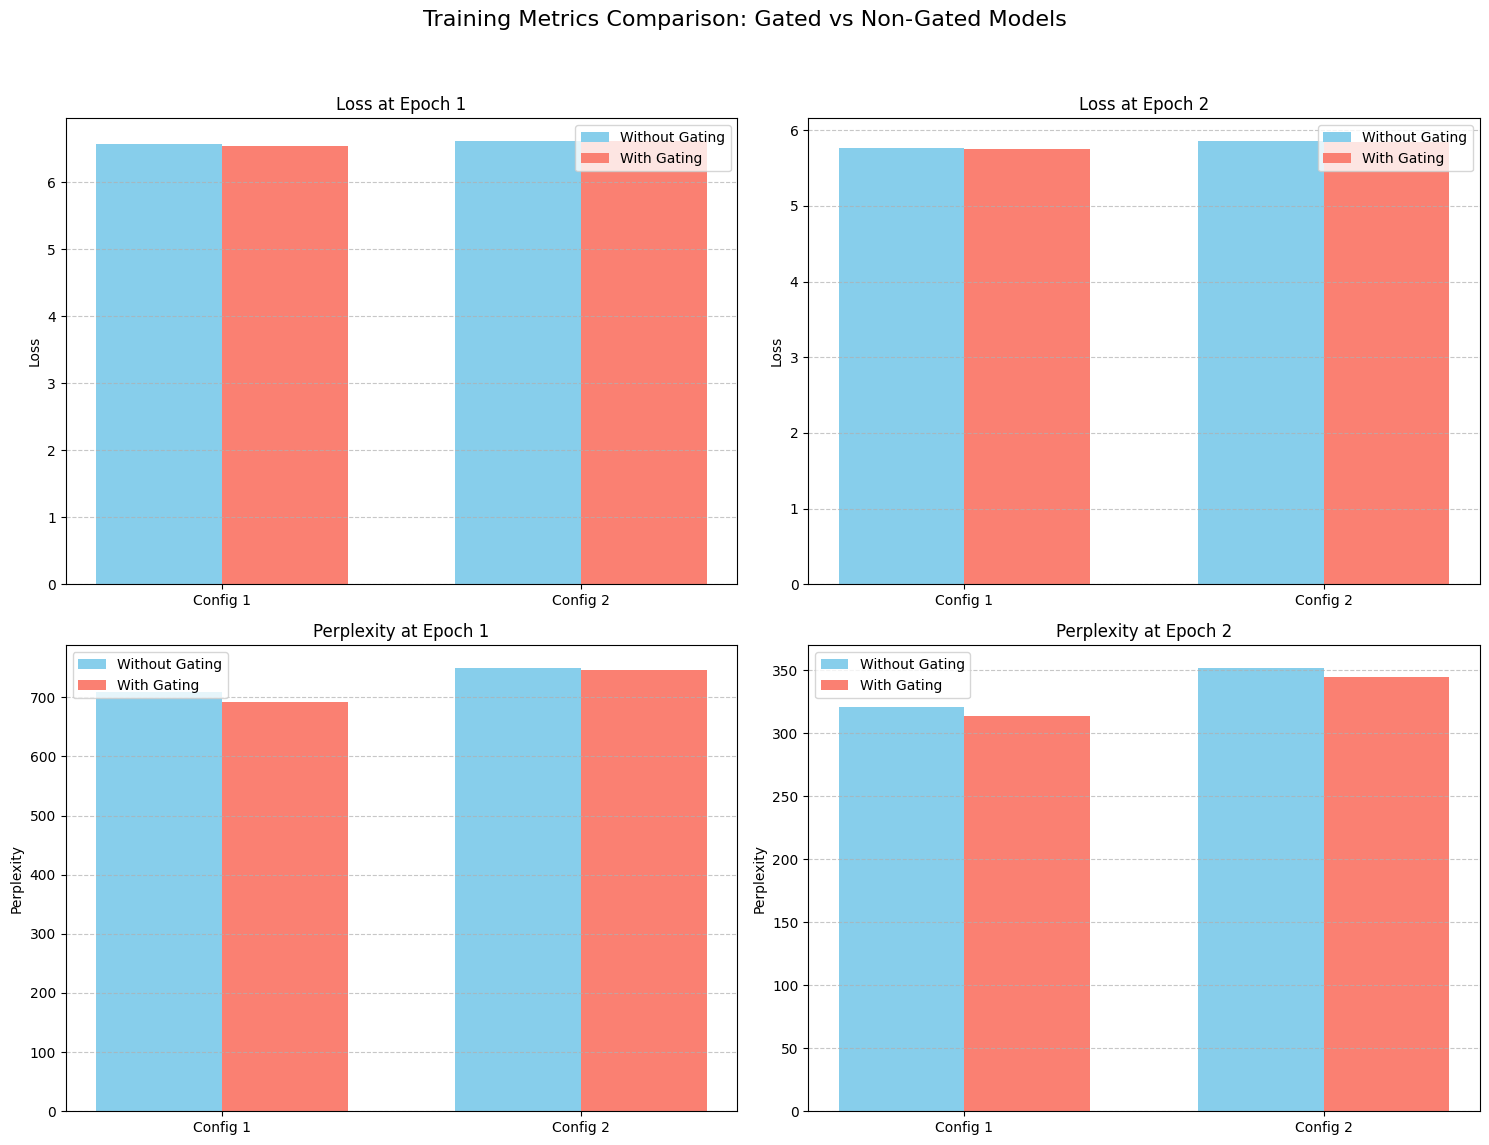

Summary Table:


Loss                         Perplexity          \
Epoch                     1     2     3     4     5          1       2   
Config Model Type                                                        
1      With Gating     6.54  5.75  5.39  5.14  4.97     691.79  313.85   
       Without Gating  6.56  5.77  5.42  5.18  4.98     709.28  320.99   
2      With Gating     6.61  5.84  5.51  5.28  5.10     745.33  344.83   
       Without Gating  6.62  5.86  5.54  5.32  5.14     750.19  352.16   

                                               
Epoch                       3       4       5  
Config Model Type                              
1      With Gating     218.81  171.03  143.56  
       Without Gating  226.42  178.04  145.69  
2      With Gating     246.82  195.53  164.15  
       Without Gating  254.42  204.37  171.25

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data for plotting
configs = [1, 2]
metrics = ['Loss', 'Perplexity']
model_types = ['Without Gating', 'With Gating']

# Collect all loss data
all_results = []

# Without Gating
for i, (loss_config, config_num) in enumerate(zip(
    [epoch_loss_no_gate_config_1, epoch_loss_no_gate_config_2],
    configs
)):
    for epoch_idx, loss_val in enumerate(loss_config):
        ppl_val = torch.exp(loss_val).item()
        all_results.append({
            'Config': config_num,
            'Model Type': 'Without Gating',
            'Epoch': epoch_idx + 1,
            'Loss': loss_val.item(),
            'Perplexity': ppl_val
        })

# With Gating
for i, (loss_config, config_num) in enumerate(zip(
    [gated_epoch_loss_config_1, gated_epoch_loss_config_2],
    configs
)):
    for epoch_idx, loss_val in enumerate(loss_config):
        ppl_val = torch.exp(loss_val).item()
        all_results.append({
            'Config': config_num,
            'Model Type': 'With Gating',
            'Epoch': epoch_idx + 1,
            'Loss': loss_val.item(),
            'Perplexity': ppl_val
        })

df_results = pd.DataFrame(all_results)

# Create a pivot table for summary display
df_pivot = df_results.pivot_table(
    index=['Config', 'Model Type'],
    columns='Epoch',
    values=['Loss', 'Perplexity']
).round(2)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Training Metrics Comparison: Gated vs Non-Gated Models', fontsize=16)

for i, metric in enumerate(metrics):
    for j, epoch in enumerate([1, 2]):
        ax = axes[i, j]

        # Filter data for specific metric and epoch
        plot_df = df_results[df_results['Epoch'] == epoch]

        x = np.arange(len(configs))
        width = 0.35

        no_gate_vals = plot_df[plot_df['Model Type'] == 'Without Gating'][metric].values
        gate_vals = plot_df[plot_df['Model Type'] == 'With Gating'][metric].values

        ax.bar(x - width/2, no_gate_vals, width, label='Without Gating', color='skyblue')
        ax.bar(x + width/2, gate_vals, width, label='With Gating', color='salmon')

        ax.set_title(f'{metric} at Epoch {epoch}')
        ax.set_xticks(x)
        ax.set_xticklabels([f'Config {c}' for c in configs])
        ax.set_ylabel(metric)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Displaying the summary table for quick reference
print("Summary Table:")
display(df_pivot)